# Dataset 1 — Ames Housing

## Descripción general
El Ames Housing Dataset contiene información sobre **2,930 casas vendidas** en la ciudad 
de Ames, Iowa (Estados Unidos) entre los años 2006 y 2010. Fue compilado por el profesor 
Dean De Cock como una alternativa moderna al clásico Boston Housing Dataset.

## Objetivo
**Problema de Regresión** — predecir el precio de venta (`SalePrice`) de una casa 
en función de sus características físicas, de calidad y de ubicación.

## Estructura original
- **Filas:** 2,930 casas
- **Columnas:** 82 en total
- **Variable objetivo:** `SalePrice` (precio en dólares, rango: $12,789 - $755,000)
- **Precio promedio:** $180,796

## Tipos de columnas
| Tipo | Cantidad | Ejemplos |
|------|----------|---------|
| Numéricas | 39 | Lot Area, Year Built, Gr Liv Area, Garage Area |
| Categóricas (texto) | 43 | MS Zoning, Neighborhood, Roof Style, Kitchen Qual |

## Columnas más importantes
- `Overall Qual` → calidad general de la casa (1-10)
- `Gr Liv Area` → superficie habitable en pies cuadrados
- `Year Built` → año de construcción
- `Neighborhood` → barrio donde está ubicada
- `Total Bsmt SF` → superficie del sótano
- `Garage Cars` → capacidad del garage
- `SalePrice` → precio de venta (**variable objetivo**)

## Valores faltantes encontrados
El dataset tenía **15,749 valores faltantes** distribuidos en 27 columnas.

## Tratamiento aplicado

### 1. Eliminación de columnas identificadoras
Se eliminaron `Order` y `PID` porque son simplemente números de fila 
y códigos de identificación — no aportan ninguna información predictiva.

### 2. Eliminación de columnas con >50% de NaN
Se eliminaron 5 columnas con demasiados valores faltantes:
- `Alley` (93.2% nulos) → tipo de callejón de acceso
- `Mas Vnr Type` (60.6% nulos) → tipo de revestimiento de mampostería  
- `Pool QC` (99.6% nulos) → calidad de la piscina
- `Fence` (80.5% nulos) → calidad del cerco
- `Misc Feature` (96.4% nulos) → características misceláneas

Imputar estas columnas no sería confiable dado que casi no tienen datos reales.

### 3. Imputación de NaN restantes
- **Columnas numéricas** → imputadas con la **mediana** de cada columna.
  Se usa la mediana en lugar del promedio porque es más resistente a valores extremos.
- **Columnas de texto** → imputadas con la etiqueta `'Desconocido'`
  para indicar explícitamente que la información no estaba disponible.

### 4. Codificación de variables categóricas
Las 43 columnas de texto fueron convertidas a números mediante **one-hot encoding** (`pd.get_dummies()`), generando una columna binaria (0 o 1) por cada valor posible.

### 5. Preparación Matemática (División y Normalización)
- **Mezcla y División (80/20):** Los registros fueron desordenados aleatoriamente (`permutation`) para evitar que el algoritmo aprenda patrones engañosos (por ejemplo, si el dataset original estaba ordenado por fechas o barrios). Luego se dividieron en **80% para entrenamiento** y **20% para validación**.
- **Normalización Z-Score:** Dado que las variables tienen escalas muy distintas (ej. el área está en miles de pies cuadrados, mientras que el número de garajes es de 1 o 2), se estandarizaron todas las características. Esto es un requisito matemático para asegurar que el algoritmo de Descenso de Gradiente converja sin que los números grandes dominen la ecuación.
- **Término de Sesgo (Bias):** Se añadió una columna de unos ($X_0 = 1$) al inicio de las matrices para representar el intercepto ($\theta_0$) que define el precio base o punto de partida del modelo.

## Resultado final
| Métrica | Antes | Después |
|--|-------|---------|
| **Filas** | 2,930 | 2,344 (Entrenamiento) / 586 (Pruebas) |
| **Columnas (Matriz X)** | 82 | 297 (Incluyendo la columna de sesgo) |
| **Valores faltantes** | 15,749 | 0 |
| **Columnas de texto** | 43 | 0 |

## ¿Está balanceado?
El balanceo aplica únicamente para problemas de clasificación. 
Este es un problema de **regresión** — la variable objetivo `SalePrice` 
es un número continuo, no una categoría. Por lo tanto, aplicar técnicas de balanceo destruiría la distribución real de precios del mercado, por lo que este concepto no aplica aquí.

Shape original: (2930, 82)
Variable objetivo - SalePrice:
  Min: $12,789
  Max: $755,000
  Media: $180,796.06

Shape después de eliminar identificadores (Order, PID): (2930, 80)

Columnas eliminadas por tener >50% de NaN:
  Alley: 93.2% nulos
  Mas Vnr Type: 60.6% nulos
  Pool QC: 99.6% nulos
  Fence: 80.5% nulos
  Misc Feature: 96.4% nulos

NaN totales restantes después de rellenar huecos: 0
Shape después de One-Hot Encoding: (2930, 296)

Dataset limpio guardado como 'AmesHousing_preparado.csv'

=== INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN ===

¡Variables listas para el algoritmo!
Tamaño X_train_norm (Datos para estudiar):  (2344, 296)
Tamaño y_train (Respuestas para estudiar):  (2344,)
Tamaño X_test_norm (Datos del examen):      (586, 296)
Tamaño y_test (Respuestas ocultas):         (586,)


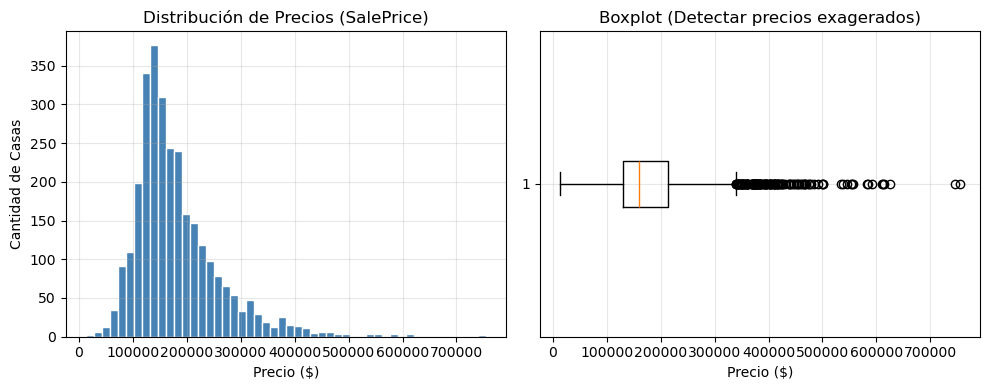

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PREPARACIÓN DATASET 1: Ames Housing (Regresión)

# 1. CARGAR
ruta_ames = r'C:\Users\Usuario\Documents\7mo semestre\Sis420\PrimerParcial\Dataset1\archive\AmesHousing.csv'
df = pd.read_csv(ruta_ames)

print("Shape original:", df.shape)
print("Variable objetivo - SalePrice:")
print(f"  Min: ${df['SalePrice'].min():,}")
print(f"  Max: ${df['SalePrice'].max():,}")
print(f"  Media: ${df['SalePrice'].mean():,.2f}")

# 2. ELIMINAR COLUMNAS INÚTILES
# Quitamos Order y PID porque son solo números de registro (como el carnet), no dicen nada de la casa.
df = df.drop(columns=['Order', 'PID'])
print("\nShape después de eliminar identificadores (Order, PID):", df.shape)

# 3. ELIMINAR COLUMNAS CON >50% DE NaN
umbral = 0.5 * len(df)
cols_muchos_nulos = df.columns[df.isnull().sum() > umbral].tolist()
print("\nColumnas eliminadas por tener >50% de NaN:")
for col in cols_muchos_nulos:
    pct = df[col].isnull().sum() / len(df) * 100
    print(f"  {col}: {pct:.1f}% nulos")
df = df.drop(columns=cols_muchos_nulos)

# 4. IMPUTAR NaN RESTANTES
# Rellenamos los números vacíos con la mediana (el valor del medio)
cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns
for col in cols_numericas:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)

# Rellenamos los textos vacíos con la palabra 'Desconocido'
cols_texto = df.select_dtypes(include='object').columns
for col in cols_texto:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna('Desconocido')

print("\nNaN totales restantes después de rellenar huecos:", df.isnull().sum().sum())

# 5. ONE-HOT ENCODING
# Convertimos todas las palabras a columnas de 0s y 1s
df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns.tolist())
print("Shape después de One-Hot Encoding:", df.shape)

# 6. MOVER SalePrice AL FINAL (Para que sea más fácil separar la X y la Y)
cols = [c for c in df.columns if c != 'SalePrice'] + ['SalePrice']
df = df[cols]

# 7. GUARDAR EL DATASET LIMPIO
df.to_csv('AmesHousing_preparado.csv', index=False)
print("\nDataset limpio guardado como 'AmesHousing_preparado.csv'")

# 8. DIVISIÓN 80/20 Y NORMALIZACIÓN MATEMÁTICA
print("\n=== INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN ===")

# Separar características (X) y el precio objetivo (y)
# Usamos .astype(float) para evitar problemas matemáticos con los True/False del One-Hot
X = df.drop('SalePrice', axis=1).astype(float).values
y = df['SalePrice'].astype(float).values

# Calcular el índice de corte para el 80%
m = len(y)
limite = int(m * 0.8)

# Mezclar las casas como si fuera una baraja de cartas para que el modelo aprenda de todo (baratas y caras)
np.random.seed(42)
indices = np.random.permutation(m)
X = X[indices]
y = y[indices]

# División: 80% para entrenar (estudiar) y 20% para testear (examen)
X_train, X_test = X[:limite], X[limite:]
y_train, y_test = y[:limite], y[limite:]

# Función manual para Normalizar (poner todas las medidas en la misma escala)
def normalizar(X_data):
    mu = np.mean(X_data, axis=0) # Promedio
    sigma = np.std(X_data, axis=0) # Desviación
    sigma[sigma == 0] = 1 # Truco para que no dé error matemático de división por cero
    X_norm = (X_data - mu) / sigma
    return X_norm, mu, sigma

# Normalizamos usando SOLO los datos de entrenamiento
X_train_norm, mu, sigma = normalizar(X_train)
X_test_norm = (X_test - mu) / sigma 

# Agregar la columna de puros "Unos" al principio (el Sesgo / Bias)
X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print("\n¡Variables listas para el algoritmo!")
print(f"Tamaño X_train_norm (Datos para estudiar):  {X_train_norm.shape}")
print(f"Tamaño y_train (Respuestas para estudiar):  {y_train.shape}")
print(f"Tamaño X_test_norm (Datos del examen):      {X_test_norm.shape}")
print(f"Tamaño y_test (Respuestas ocultas):         {y_test.shape}")

# =========================================================
# 9. GRÁFICAS FINALES
# =========================================================
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
plt.title("Distribución de Precios (SalePrice)")
plt.xlabel("Precio ($)")
plt.ylabel("Cantidad de Casas")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df['SalePrice'], vert=False)
plt.title("Boxplot (Detectar precios exagerados)")
plt.xlabel("Precio ($)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()